In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import re
import os
import kagglehub

# 0. Download dataset through Kagglehub
Dataset Path: "parisrohan/credit-score-classification" \
Use the os module to construct the file path for the dataset. \
Load the training dataset into a Pandas DataFrame. \
Also, output the infomations using info() mathod.

In [2]:
path = kagglehub.dataset_download("parisrohan/credit-score-classification")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in the dataset directory:", files)
file_name = 'train.csv'
file_path = os.path.join(path, file_name)

df = pd.read_csv(file_path)
df.info()

Path to dataset files: C:\Users\asus\.cache\kagglehub\datasets\parisrohan\credit-score-classification\versions\1
Files in the dataset directory: ['test.csv', 'train.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null 

C:\Users\asus\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3185: DtypeWarning: Columns (26) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


# 1. Data Clean & EDA

Load first 5 rows in the dataframe using head() method.

In [3]:
df.head(5)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 1.1 Data Clean
We have numerical and categorical types of features in our dataset. Among them, the numerical features are the main and useful part of our data. But from our observation, we found the data is not very clean and well-formatted. In this section we will clean both the numerical and categorcial features.

Copy the original DataFrame to `df_cleaned`, which will be used for data cleaning.

In [4]:
df_cleaned = df.copy()
df_cleaned.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

Drop the columns containing personal information: ID, Customer_ID, Month, Name, and SSN.

In [5]:
drop_columns = ['ID','Customer_ID','Month','Name','SSN']
df_cleaned = df_cleaned.drop(drop_columns, axis = 1)
df_cleaned.shape

(100000, 23)

### 1.1.1 Numerical Data
From observing the data, we found some numerical values contain "_" character. Some values are not in a normal range, e.g. the 'age' column has negative values. We will format all values and drop the rows with irregular data.

In [6]:
# The numeric columns: 8
numerical_columns = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate','Delay_from_due_date', 'Num_of_Loan', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly',
    'Monthly_Balance', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries'
]
len(numerical_columns)

16

In [7]:
df_cleaned.select_dtypes('number').columns

Index(['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month'],
      dtype='object')

Use str.replace() to correct typos in numerical values in the columns of a DataFrame.

In [8]:
df_cleaned['Age'] = df_cleaned['Age'].str.replace(r'_', '', regex=True).astype(int)
df_cleaned['Num_of_Loan'] = df_cleaned['Num_of_Loan'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Annual_Income'] = df_cleaned['Annual_Income'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Outstanding_Debt'] = df_cleaned['Outstanding_Debt'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Monthly_Balance'] = df_cleaned['Monthly_Balance'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Num_of_Delayed_Payment'] = df_cleaned['Num_of_Delayed_Payment'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Amount_invested_monthly'] = df_cleaned['Amount_invested_monthly'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Changed_Credit_Limit'] = df_cleaned['Changed_Credit_Limit'].str.replace(r'_', '', regex=True).replace('', np.nan).astype(float)

1. Convert Columns to Numeric: Use pd.to_numeric to convert the specified columns to a numeric data type. \
2. Clean Age Column: Remove rows where the Age value is less than 0 or greater than 100. \
3. Filter Num_of_Loan Column: Retain only rows where Num_of_Loan has values greater than 0. \
4. Adjust Negative Values: For Num_Bank_Accounts and Num_of_Delayed_Payment, replace all negative values with 0. \
5. Define a Conversion Method: Implement the following method to convert Credit_History_Age to a float number of days: \
6. Handle Missing Values: Impute missing values in the dataset using the median of the respective columns. \
7. Remove Outliers: Apply clipping to limit values in the dataset to the 1st and 99th percentiles. \

In [9]:
# Convert Data Types: Ensure numeric format
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].apply(
    pd.to_numeric, errors='coerce'
)

# Drop all rows of age less than 0
df_cleaned = df_cleaned[(df_cleaned['Age'] >= 0) & (df_cleaned['Age'] <= 100)]

# Drop all the num of loans less than 0
df_cleaned = df_cleaned[df_cleaned['Num_of_Loan']>=0]

# Reset all negative Num_Bank_Accounts to 0
df_cleaned.loc[df_cleaned['Num_Bank_Accounts']<0,'Num_Bank_Accounts'] = 0

# Reset all negative Num_of_Delayed_Payment to 0
df_cleaned.loc[df_cleaned['Num_of_Delayed_Payment']<0,'Num_of_Delayed_Payment'] = 0

#Convert Credit_History_Age to a float number of days
def age2days(text, years=0, months=0):
    # Validate and handle empty or invalid input
    if not text or not isinstance(text, str):
        return 0  # Return 0 if text is empty or invalid

    days_in_year = 365.25
    days_in_month = 30.44

    years_match = re.search(r'(\d+)\s*Years?', text, re.IGNORECASE)
    months_match = re.search(r'(\d+)\s*Months?', text, re.IGNORECASE)

    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0

    return int((years * days_in_year) + (months * days_in_month))

df_cleaned['Credit_History_Age'] = df_cleaned['Credit_History_Age'].apply(age2days)

# Handle Missing Values: Impute with median
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].apply(
    lambda x: x.fillna(x.median())
)


# Remove Outliers: Clip to 1st and 99th percentile
for column in numerical_columns:
    lower = df_cleaned[column].quantile(0.01)
    upper = df_cleaned[column].quantile(0.99)
    df_cleaned[column] = df_cleaned[column].clip(lower, upper)

### 1.1.2 Categorical Data
Correct the typo in categorical data.

In [10]:
#Replace the '_______' value in the Occupation field with Other
df_cleaned['Occupation'] = df_cleaned['Occupation'].replace('_______', 'Other')

#Correct Typo
df_cleaned['Payment_of_Min_Amount'] = df_cleaned['Payment_of_Min_Amount'].str.replace('NM', 'No')

#Drop Typo
df_cleaned = df_cleaned[df_cleaned['Payment_Behaviour']!='!@9#%8']

In [11]:
# hasn't done processing yet, drop for now

df_cleaned.drop(columns=['Type_of_Loan'],inplace=True)
df_cleaned.drop(columns=['Credit_Mix'],inplace=True)

## 1.2 EDA
After the data cleansing process, we visualize some key features of our data to help us better understand the data.

Use a countplot to visualize the distribution of choices in the 'Credit_Score' column.

C:\Users\asus\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(array([0, 1, 2]),
 [Text(0, 0, 'Good'), Text(1, 0, 'Standard'), Text(2, 0, 'Poor')])

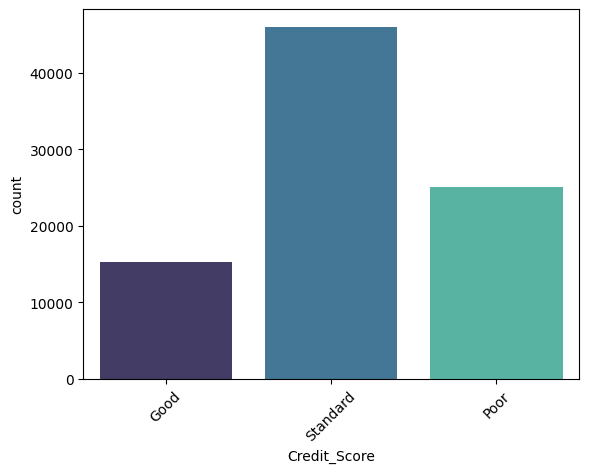

In [12]:
sns.countplot(df_cleaned['Credit_Score'],palette="mako")
plt.xticks(rotation=45)

Iterate through each numerical column to visualize its distribution using a histogram.

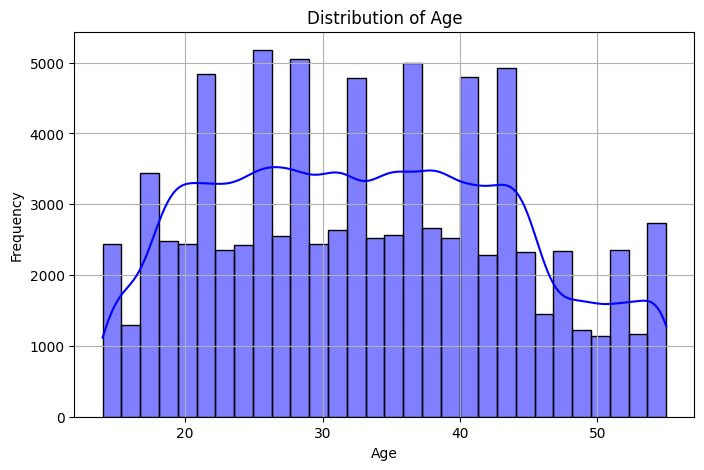

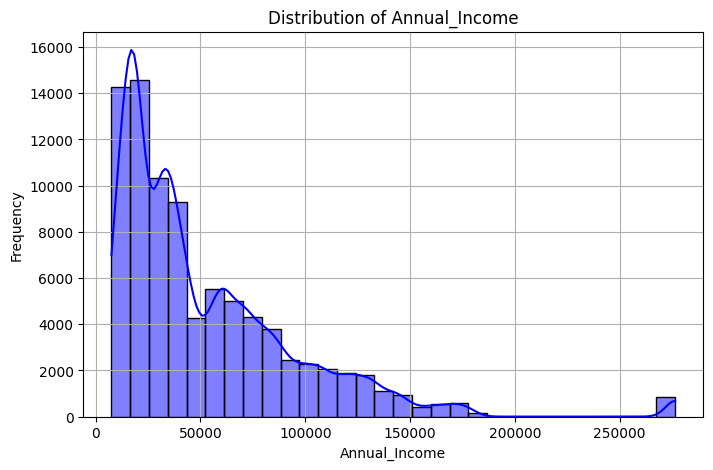

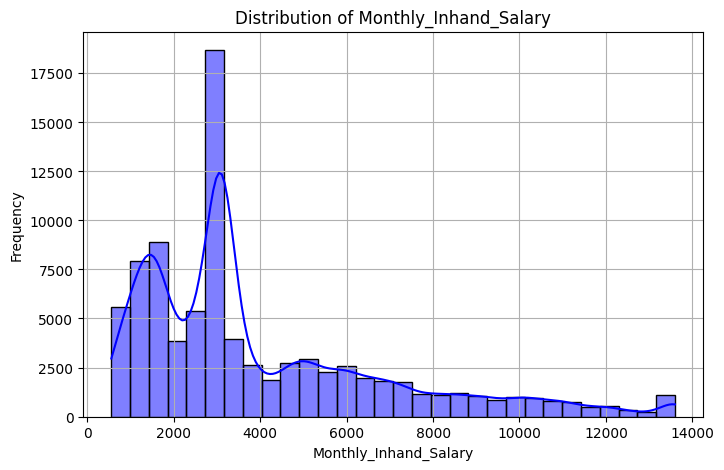

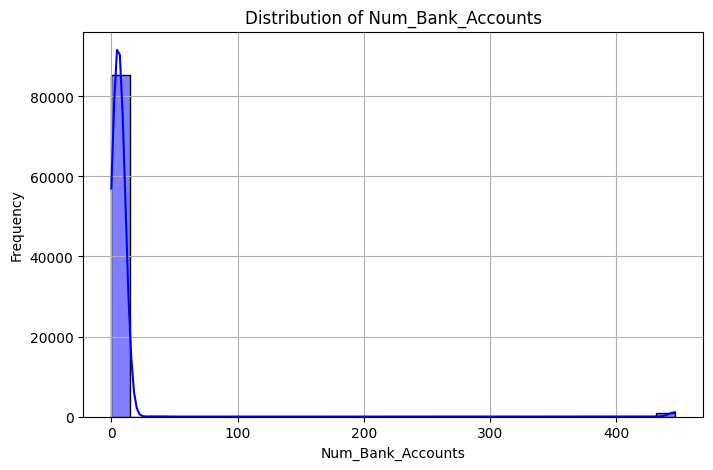

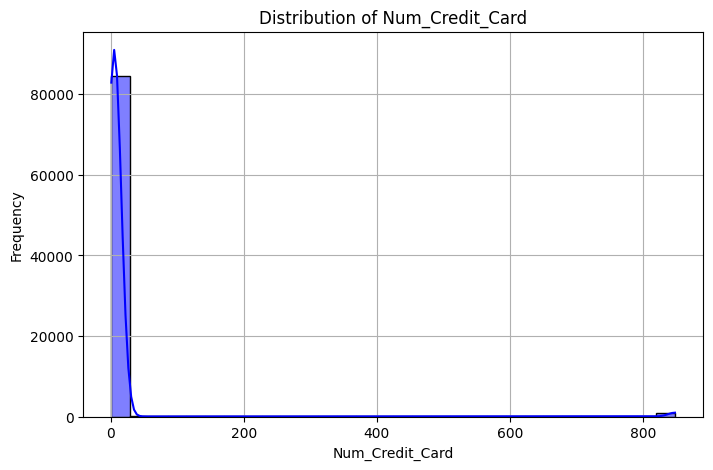

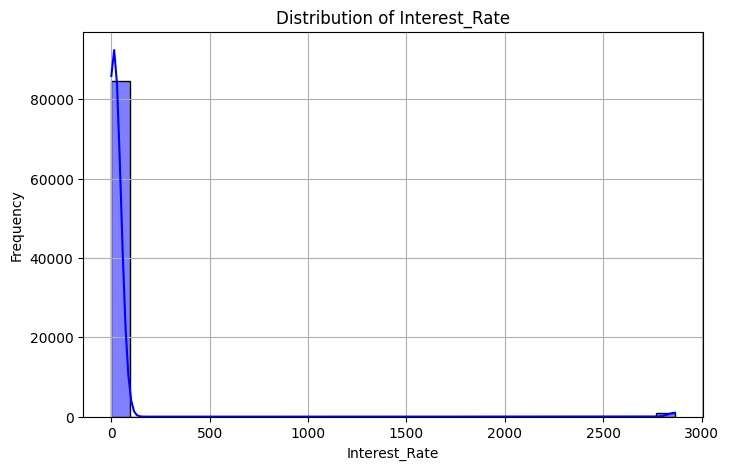

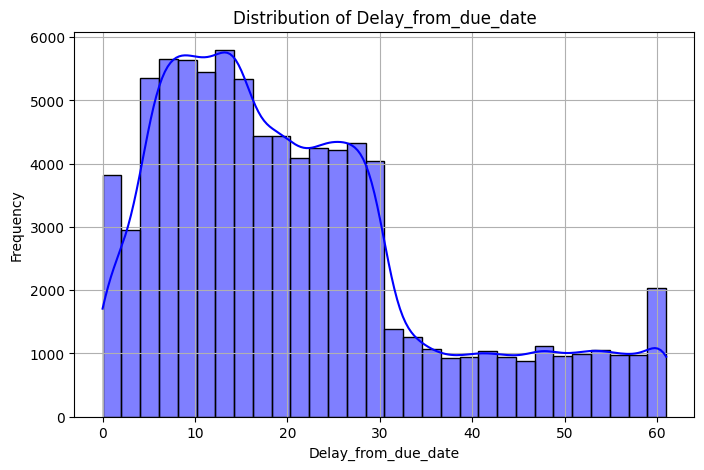

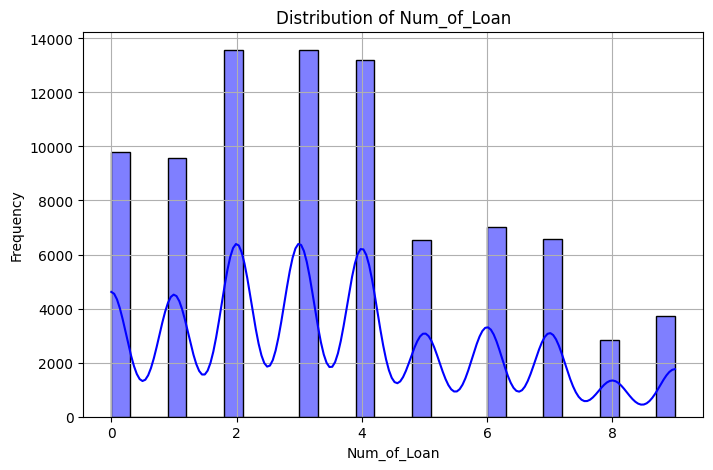

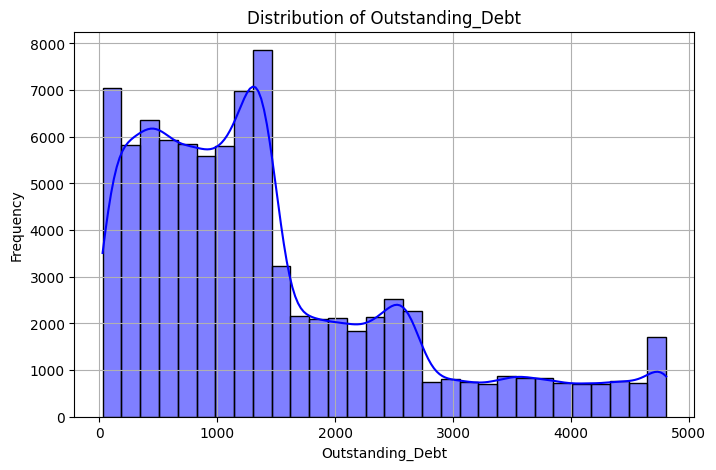

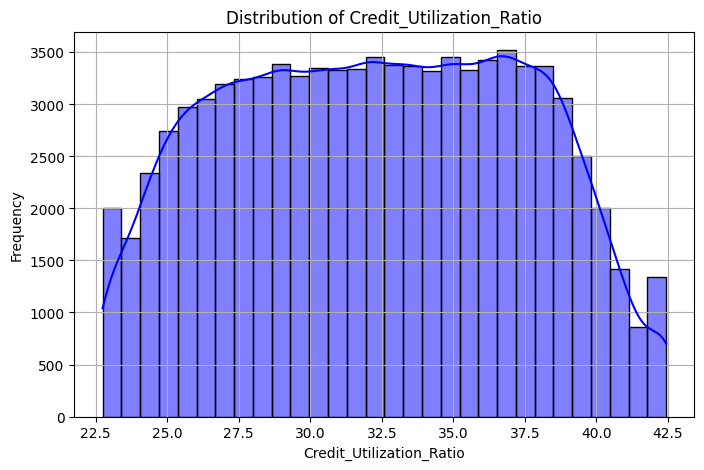

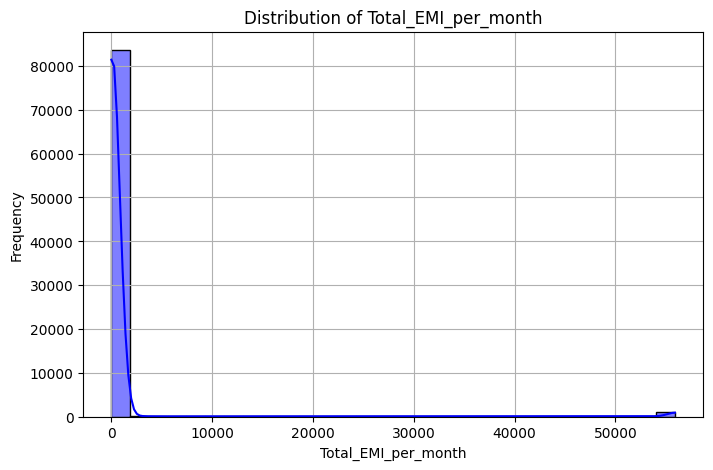

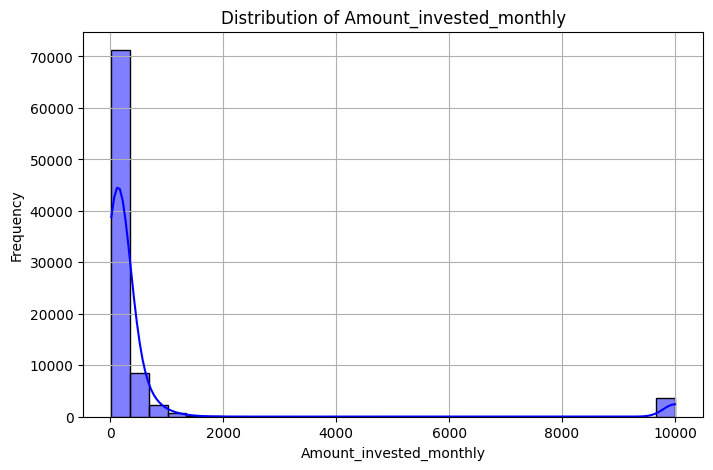

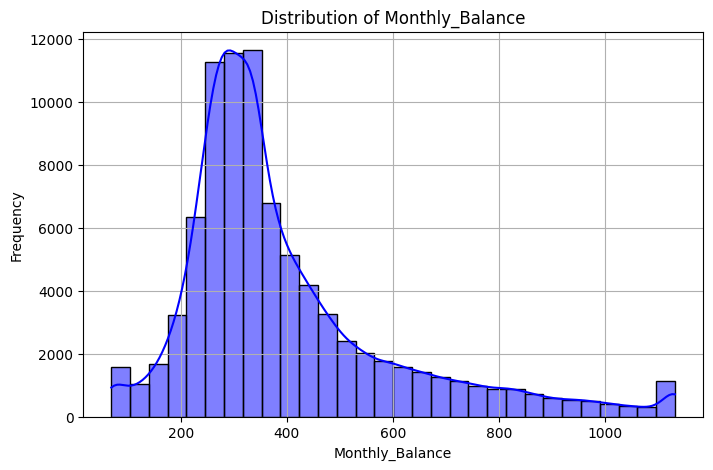

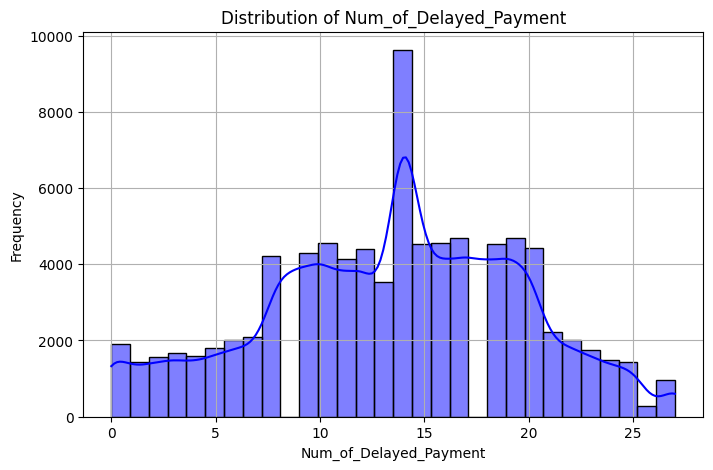

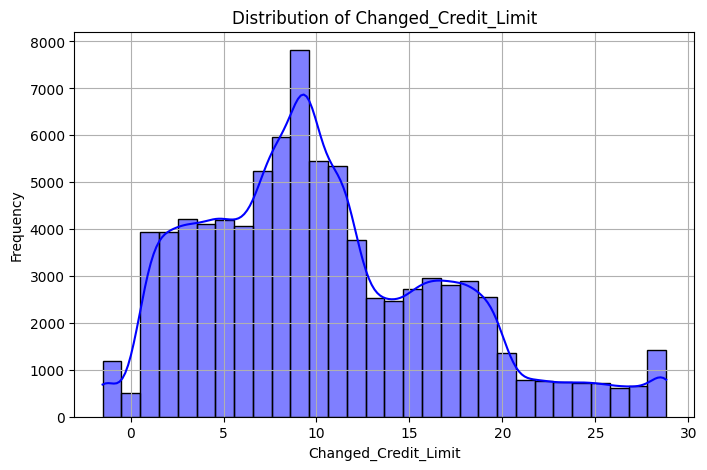

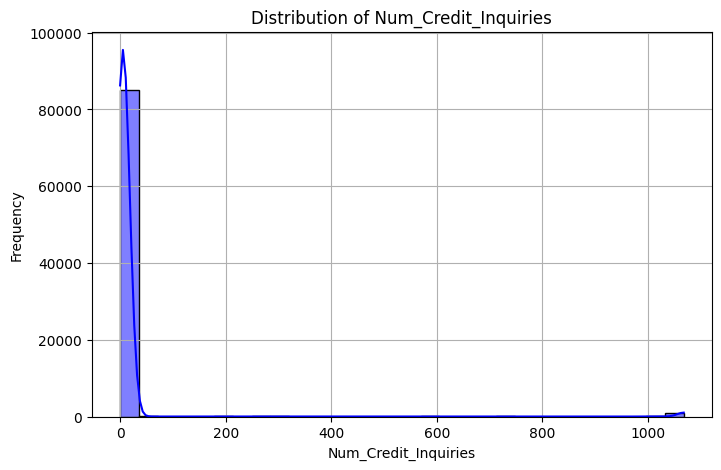

In [13]:
# Set up visualizations
for numerical_column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_cleaned[numerical_column], kde=True, bins=30, color='blue', edgecolor='black')
    plt.title(f'Distribution of {numerical_column}')
    plt.xlabel(numerical_column)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# 2. Feature Engineering

## 2.1 Encode the categorical columns

For the categorical columns, apply one-hot encoding to transform them.

In [14]:
df_final = df_cleaned.copy()
df_final.head().T

,0,1,3,4,6
Age,23,23,23,23,23
Occupation,Scientist,Scientist,Scientist,Scientist,Scientist
Annual_Income,19114.12,19114.12,19114.12,19114.12,19114.12
Monthly_Inhand_Salary,1824.843333,3095.905,3095.905,1824.843333,1824.843333
Num_Bank_Accounts,3.0,3.0,3.0,3.0,3.0
Num_Credit_Card,4.0,4.0,4.0,4.0,4.0
Interest_Rate,3.0,3.0,3.0,3.0,3.0
Num_of_Loan,4.0,4.0,4.0,4.0,4.0
Delay_from_due_date,3,0,5,6,3
Num_of_Delayed_Payment,7.0,14.0,4.0,14.0,8.0


In [15]:
df_final['Payment_of_Min_Amount'] = pd.get_dummies(df_final['Payment_of_Min_Amount'], columns=['Payment_of_Min_Amount'],prefix='Payment_of_Min_Amount',dtype=float,drop_first=True)

one_hot_encoding_columns = ['Occupation', 'Payment_Behaviour']
one_hot_encoded_columns = pd.get_dummies(df_final[one_hot_encoding_columns], dtype=float)
df_final = df_final.drop(columns=one_hot_encoding_columns).join(one_hot_encoded_columns)

In [16]:
X = df_final.drop(columns=['Credit_Score'])
X.head().T

,0,1,3,4,6
Age,23.000000,23.000000,23.000000,23.000000,23.000000
Annual_Income,19114.120000,19114.120000,19114.120000,19114.120000,19114.120000
Monthly_Inhand_Salary,1824.843333,3095.905000,3095.905000,1824.843333,1824.843333
Num_Bank_Accounts,3.000000,3.000000,3.000000,3.000000,3.000000
Num_Credit_Card,4.000000,4.000000,4.000000,4.000000,4.000000
Interest_Rate,3.000000,3.000000,3.000000,3.000000,3.000000
Num_of_Loan,4.000000,4.000000,4.000000,4.000000,4.000000
Delay_from_due_date,3.000000,0.000000,5.000000,6.000000,3.000000
Num_of_Delayed_Payment,7.000000,14.000000,4.000000,14.000000,8.000000
Changed_Credit_Limit,11.270000,11.270000,6.270000,11.270000,11.270000


Perform label encoding to convert the Credit_Score column.

In [17]:
# We use label encoder for our target label
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df_final['Credit_Score'])
y

array([0, 0, 0, ..., 1, 1, 2])

## 2.2 Correlation Matrix

Generate a correlation matrix for the numerical features to gain valuable insights and identify potentially relevant features.

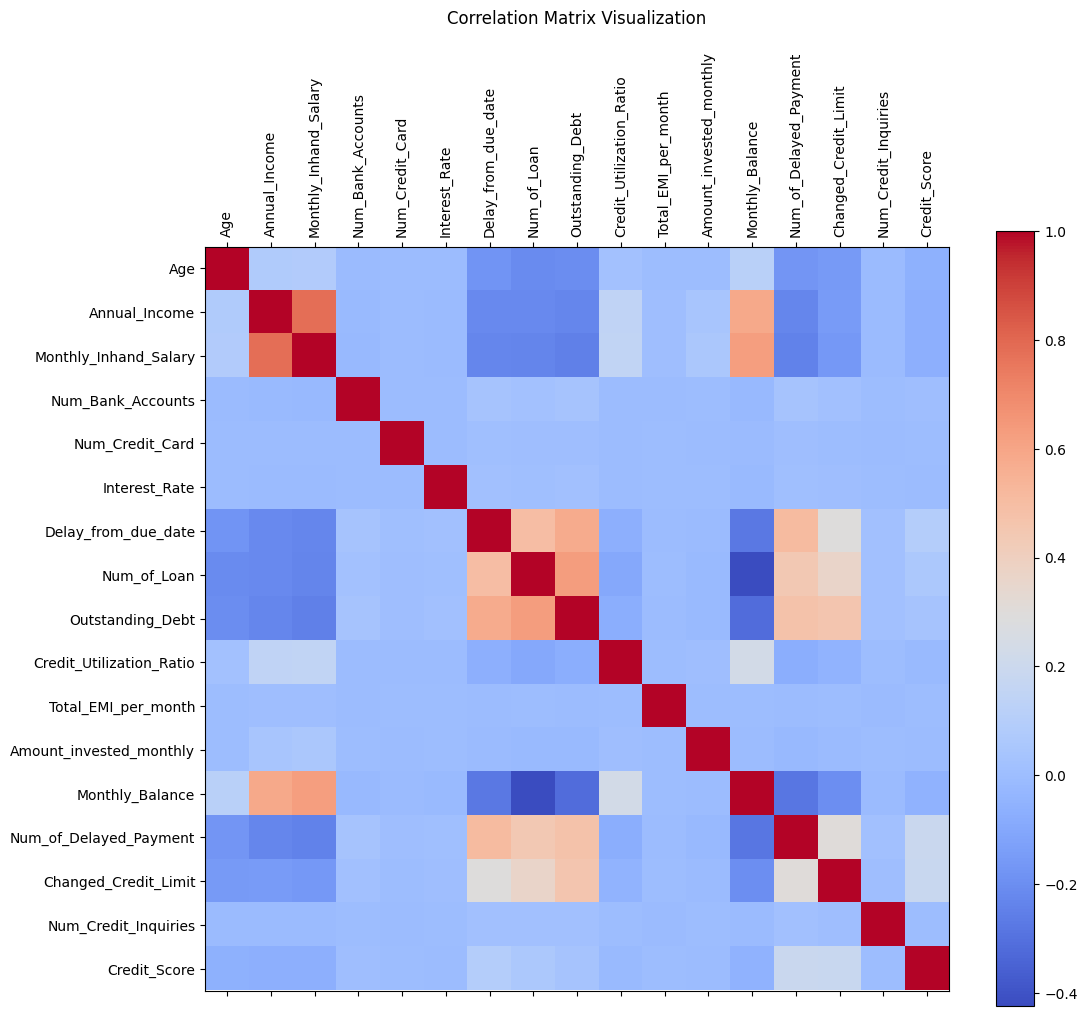

In [18]:
df_final['Credit_Score'] = label_encoder.fit_transform(df_final['Credit_Score'])
correlation_matrix = df_final[numerical_columns+['Credit_Score']].corr()


# Plotting the correlation matrix
plt.figure(figsize=(12, 10))
plt.matshow(correlation_matrix, fignum=1, cmap='coolwarm')

# Adding colorbar and labels
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Adding title
plt.title("Correlation Matrix Visualization", pad=20)
plt.show()


# 3. Modeling

## 3.1 Normalization & Split
1. Normalization using StandardScaler()
2. spliting train set and test set using train_test_split() with random_state = 42.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.2 Base line model: logistic regression

use LogisticRegression() without passing any parameters.

In [29]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred_lr)
acc = accuracy_score(y_test, y_pred_lr)
print(f"Test Accuracy: {acc:.4f}, Test Loss: {mse:.4f}")

Test Accuracy: 0.6073, Test Loss: 0.8640


## 3.3 Advanced model

### 3.3.1 Decision Tree
greedily search the optimal parameters: \
param_grid_dt = { \
    'criterion': ['gini', 'entropy'], \
    'max_depth': [None, 5, 10, 15, 20], \
    'min_samples_split': [2, 5, 10],  \
    'min_samples_leaf': [1, 2, 5, 10] \
}
- **`criterion`**: Determines the function used to evaluate the quality of a split.  
- **`max_depth`**: Limits the maximum depth of the tree to mitigate overfitting.  
- **`min_samples_split`**: Defines the minimum number of samples needed to split an internal node.  
- **`min_samples_leaf`**: Indicates the minimum number of samples required for a leaf node.  

The model's performance will be evaluated using **accuracy** as the metric, employing **5-fold cross-validation (cv=5)** for reliable validation.


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 5, 10],
}
grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, scoring='accuracy', cv=5, verbose=1)
grid_search_dt.fit(X_train_scaled, y_train)

best_params_dt = grid_search_dt.best_params_
best_model_dt = grid_search_dt.best_estimator_
print(f"Best Hyperparameters: {best_params_dt}")

y_pred_dt = best_model_dt.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred_dt)
accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Test Accuracy: {accuracy:.4f}, Test Loss: {mse:.4f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Test Accuracy: 0.7112, Test Loss: 0.6361


Feature Importance Visualization

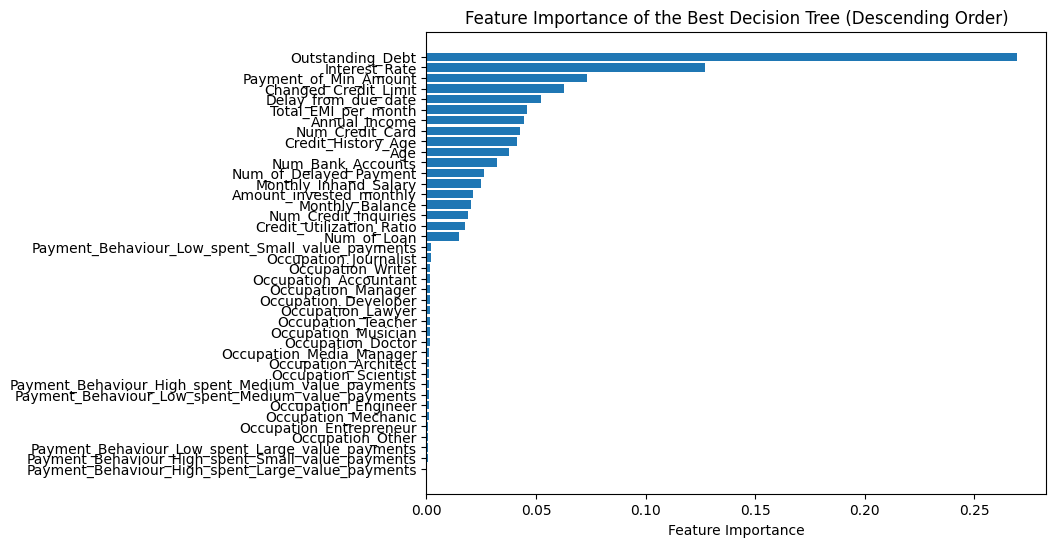

In [26]:
feature_names = df_final.drop(columns=['Credit_Score'], axis=1).columns
feature_importances = best_model_dt.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_feature_names = feature_names[sorted_idx]
sorted_importances = feature_importances[sorted_idx]
plt.figure(figsize=(8, 6))
plt.barh(range(len(sorted_importances)), sorted_importances, align='center')
plt.yticks(range(len(sorted_importances)), sorted_feature_names)
plt.xlabel('Feature Importance')
plt.title('Feature Importance of the Best Decision Tree (Descending Order)')
plt.gca().invert_yaxis()
plt.show()

### 3.3.2 Dimensionality reduction Using Feature Importance from a Decision Tree

We observe that the top 18 features in the feature importance ranking have significantly high weights. Therefore, we propose reducing the dimensionality of the data to 18, aiming to retain more details while lowering computational costs.

In [39]:
important_features = sorted_feature_names[:18]
important_X = X[important_features]
X_train, X_test, y_train, y_test = train_test_split(important_X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_reduced = scaler.fit_transform(X_train)
X_test_reduced = scaler.transform(X_test)

### 3.3.3 XGBoost
greedily search the optimal parameters: \
param_grid_xgb = { \
    'n_estimators': [50, 100, 200], \
    'max_depth': [3, 6, 9], \
    'learning_rate': [0.01, 0.1], \
    'subsample': [0.8, 1.0], \
    'colsample_bytree': [0.8, 1.0] \
}

- **`n_estimators`**: Defines the number of boosting rounds (trees) in the model. 
- **`max_depth`**: Sets the maximum depth of each tree, influencing the model's ability to capture intricate patterns. 
- **`learning_rate`**: Adjusts the weight of each tree's contribution to the overall model, striking a balance between faster convergence and avoiding overfitting. 
- **`subsample`**: Specifies the fraction of training data used to build each tree, encouraging diversity and reducing the risk of overfitting. 
- **`colsample_bytree`**: Determines the proportion of features used for building each tree, enhancing the model's robustness. 

Model performance will be assessed using accuracy as the evaluation metric, with 5-fold cross-validation (`cv=5`) ensuring reliable and consistent validation.

In [ ]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb,
                           scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

grid_search_xgb.fit(X_train_reduced, y_train)

best_params_xgb = grid_search_xgb.best_params_
best_model_xgb = grid_search_xgb.best_estimator_
print(f"Best Hyperparameters: {best_params_xgb}")

y_pred_xgb = best_model_xgb.predict(X_test_reduced)
mse = mean_squared_error(y_test, y_pred_xgb)
accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"Test Accuracy: {accuracy:.4f}, Test Loss: {mse:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


C:\Users\asus\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [16:43:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.8}
Test Accuracy: 0.7716, Test Loss: 0.5173


### 3.3.4 Random Forest

In [47]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 6, 9, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf,
                              scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

grid_search_rf.fit(X_train_reduced, y_train)

best_params_rf = grid_search_rf.best_params_
best_model_rf = grid_search_rf.best_estimator_
print(f"Best Hyperparameters: {best_params_rf}")

y_pred_rf = best_model_rf.predict(X_test_reduced)

mse = mean_squared_error(y_test, y_pred_rf)
accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Test Accuracy: {accuracy:.4f}, Test Loss: {mse:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Test Accuracy: 0.7846, Test Loss: 0.4926


# 4. Analysis 

## Generate a confusion matrix for each model.

### 4.1 Confusion Matrix for Logistic Regression (baseline)

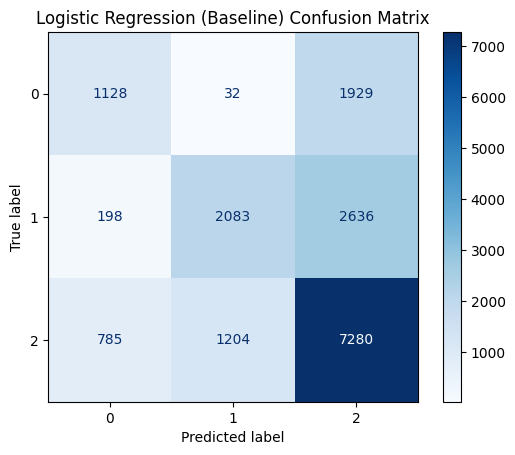

In [41]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues)

plt.title('Logistic Regression (Baseline) Confusion Matrix')
plt.show()

### 4.2 Confusion Matrix for Decision Tree

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues)

plt.title('Decision Tree Confusion Matrix')
plt.show()

### 4.3 Confusion Matrix for XGBoost

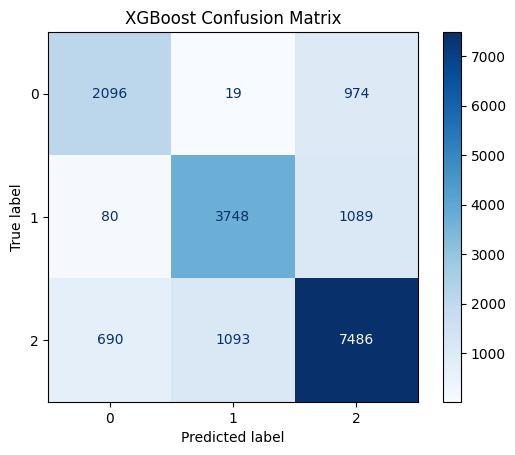

In [42]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues)

plt.title('XGBoost Confusion Matrix')
plt.show()

### 4.4 Confusion Matrix for Random Forest

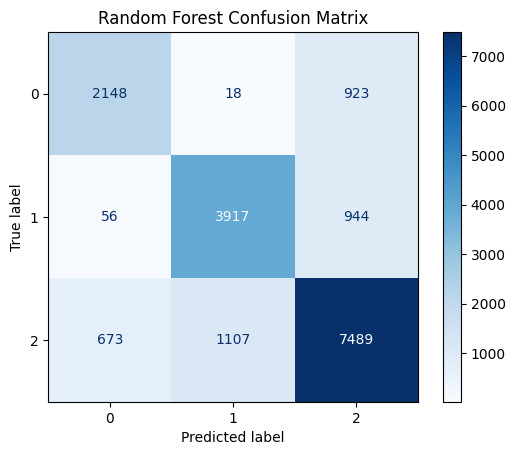

In [48]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap=plt.cm.Blues)

plt.title('Random Forest Confusion Matrix')
plt.show()